# Score-Based generative modelling using SDE

In [ ]:
# Import the relevant modules

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
from PIL import Image

import torch
import functools
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
import tqdm

In [ ]:
!pip install torchinfo
from torchinfo import summary

## Define the model

In [ ]:
class GaussianFourierProjection(nn.Module):
  """Gaussian random features for encoding time steps."""  
  def __init__(self, embed_dim, scale=30.):
    super().__init__()
    # Randomly sample weights during initialization. These weights are fixed 
    # during optimization and are not trainable.
    self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
  def forward(self, x):
    x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
    return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)


class Dense(nn.Module):
  """A fully connected layer that reshapes outputs to feature maps."""
  def __init__(self, input_dim, output_dim):
    super().__init__()
    self.dense = nn.Linear(input_dim, output_dim)
  def forward(self, x):
    return self.dense(x)[..., None, None]


class ScoreNet(nn.Module):
  """A time-dependent score-based model built upon U-Net architecture."""

  def __init__(self, marginal_prob_std, channels=[32, 64, 128, 256], embed_dim=256):
    """Initialize a time-dependent score-based network.

    Args:
      marginal_prob_std: A function that takes time t and gives the standard
        deviation of the perturbation kernel p_{0t}(x(t) | x(0)).
      channels: The number of channels for feature maps of each resolution.
      embed_dim: The dimensionality of Gaussian random feature embeddings.
    """
    super().__init__()
    # Gaussian random feature embedding layer for time
    self.embed = nn.Sequential(GaussianFourierProjection(embed_dim=embed_dim),
         nn.Linear(embed_dim, embed_dim))
    
    # Encoding layers where the resolution decreases
    self.conv1 = nn.Conv2d(3, channels[0], 3, stride=1, bias=False)
    self.dense1 = Dense(embed_dim, channels[0])
    self.gnorm1 = nn.GroupNorm(4, num_channels=channels[0])
    self.conv2 = nn.Conv2d(channels[0], channels[1], 3, stride=2, bias=False)
    self.dense2 = Dense(embed_dim, channels[1])
    self.gnorm2 = nn.GroupNorm(32, num_channels=channels[1])
    self.conv3 = nn.Conv2d(channels[1], channels[2], 3, stride=2, bias=False)
    self.dense3 = Dense(embed_dim, channels[2])
    self.gnorm3 = nn.GroupNorm(32, num_channels=channels[2])
    self.conv4 = nn.Conv2d(channels[2], channels[3], 3, stride=2, bias=False)
    self.dense4 = Dense(embed_dim, channels[3])
    self.gnorm4 = nn.GroupNorm(32, num_channels=channels[3])    

    # Decoding layers where the resolution increases
    self.tconv4 = nn.ConvTranspose2d(channels[3], channels[2], 3, stride=2, bias=False, output_padding=1)
    self.dense5 = Dense(embed_dim, channels[2])
    self.tgnorm4 = nn.GroupNorm(32, num_channels=channels[2])
    self.tconv3 = nn.ConvTranspose2d(channels[2] + channels[2], channels[1], 3, stride=2, bias=False, output_padding=1)    
    self.dense6 = Dense(embed_dim, channels[1])
    self.tgnorm3 = nn.GroupNorm(32, num_channels=channels[1])
    self.tconv2 = nn.ConvTranspose2d(channels[1] + channels[1], channels[0], 3, stride=2, bias=False, output_padding=1)    
    self.dense7 = Dense(embed_dim, channels[0])
    self.tgnorm2 = nn.GroupNorm(32, num_channels=channels[0])
    self.tconv1 = nn.ConvTranspose2d(channels[0] + channels[0], 3, 3, stride=1)
    
    # The swish activation function
    self.act = lambda x: x * torch.sigmoid(x)
    self.marginal_prob_std = marginal_prob_std
  
  def forward(self, x, t): 
    # Obtain the Gaussian random feature embedding for t   
    embed = self.act(self.embed(t))    
    # Encoding path
    h1 = self.conv1(x)    
    ## Incorporate information from t
    h1 += self.dense1(embed)
    ## Group normalization
    h1 = self.gnorm1(h1)
    h1 = self.act(h1)
    h2 = self.conv2(h1)
    h2 += self.dense2(embed)
    h2 = self.gnorm2(h2)
    h2 = self.act(h2)
    h3 = self.conv3(h2)
    h3 += self.dense3(embed)
    h3 = self.gnorm3(h3)
    h3 = self.act(h3)
    h4 = self.conv4(h3)
    h4 += self.dense4(embed)
    h4 = self.gnorm4(h4)
    h4 = self.act(h4)

    # Decoding path
    h = self.tconv4(h4)
    ## Skip connection from the encoding path
    h += self.dense5(embed)
    h = self.tgnorm4(h)
    h = self.act(h)
    h = self.tconv3(torch.cat([h, h3], dim=1))
    h += self.dense6(embed)
    h = self.tgnorm3(h)
    h = self.act(h)
    h = self.tconv2(torch.cat([h, h2], dim=1))
    h += self.dense7(embed)
    h = self.tgnorm2(h)
    h = self.act(h)
    h = self.tconv1(torch.cat([h, h1], dim=1))

    # Normalize output
    h = h / self.marginal_prob_std(t)[:, None, None, None]
    return h

## Setting up the SDE

The SDE chosen to perturb the data distribution is 

$$
d\textbf{x} = \sigma^t d\textbf{w}, ~~~ t ∈ [0,1]
$$

Then, the perturbation kernel is given as 

$$
p_{0t}(\textbf{x}(t)|\textbf{x}(0)) = \mathcal{N}\left(\textbf{x}(t); \textbf{x}(0), \frac{1}{2\log{\sigma}}(\sigma^{2t}-1)\mathbb{I}\right).
$$

The above equation is essentially:

$$
\textbf{x}(t) = \textbf{x}(0) + \frac{1}{2\log{\sigma}}(\sigma^{2t}-1)\textbf{z},
$$

where $\textbf{z} \sim \mathcal{N}(0, \mathbb{I})$. 

- Note: For differential equation other than the one used above, the function $p_{0t}(\textbf{x}(t)|\textbf{x}(0))$ will be different. All we need to do is calculate this function and we can follow the steps below without any change. 

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def marginal_prob_std(t, sigma):
  """Compute the mean and standard deviation of $p_{0t}(x(t) | x(0))$.

  Args:    
    t: A vector of time steps.
    sigma: The $\sigma$ in our SDE.  
  
  Returns:
    The standard deviation.
  """    
  t = torch.tensor(t, device=device)
  return torch.sqrt((sigma**(2 * t) - 1.) / 2. / np.log(sigma))

def diffusion_coeff(t, sigma):
  """Compute the diffusion coefficient of our SDE.

  Args:
    t: A vector of time steps.
    sigma: The $\sigma$ in our SDE.
  
  Returns:
    The vector of diffusion coefficients.
  """
  return torch.tensor(sigma**t, device=device)
  
sigma =  25.0
marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=sigma)
diffusion_coeff_fn = functools.partial(diffusion_coeff, sigma=sigma)

## Define the loss function

In [ ]:
def loss_fn(model, x, marginal_prob_std, eps=1e-5):
  """The loss function for training score-based generative models.

  Args:
    model: A PyTorch model instance that represents a 
      time-dependent score-based model.
    x: A mini-batch of training data.    
    marginal_prob_std: A function that gives the standard deviation of 
      the perturbation kernel.
    eps: A tolerance value for numerical stability.
  """
  random_t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps  
  z = torch.randn_like(x)
  std = marginal_prob_std(random_t)
  perturbed_x = x + z * std[:, None, None, None]
  score = model(perturbed_x, random_t)
  loss = torch.mean(torch.sum((score * std[:, None, None, None] + z)**2, dim=(1,2,3)))
  return loss

## Load the dataset for training

In [ ]:
score_model = torch.nn.DataParallel(ScoreNet(marginal_prob_std=marginal_prob_std_fn))
score_model = score_model.to(device)


## size of a mini-batch
batch_size =  1


dataset = MNIST('.', train=True, transform=transforms.ToTensor(), download=True)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

/usr/local/lib/python3.7/dist-packages/torch/utils/data/dataloader.py:490: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


## Playground

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
from torchvision.utils import make_grid

def show_batch(batch):
    figure(figsize=(6, 6), dpi=100)
    im = make_grid(batch)
    plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))
    plt.axis("off")

/usr/local/lib/python3.7/dist-packages/torch/utils/data/dataloader.py:490: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


torch.Size([1, 1, 28, 28])


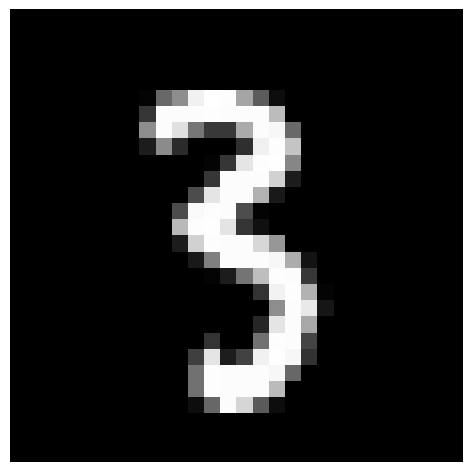

In [ ]:
images, labels = next(iter(data_loader))
images = images.to(device)

print(images.shape)
show_batch(images.cpu())

In [ ]:
eps=1e-5
random_t = torch.rand(images.shape[0], device=images.device) * (1. - eps) + eps 
print(random_t)

tensor([0.3787], device='cuda:0')


In [ ]:
z = torch.randn_like(images).to(device)
print(f"z shape = {z.shape}")
z.get_device()

z shape = torch.Size([1, 1, 28, 28])


0

In [ ]:
std = marginal_prob_std_fn(random_t).to(device)
print(std.shape)
print(std[:, None, None, None].shape)
#print(std[:, None, None, None])

torch.Size([1])
torch.Size([1, 1, 1, 1])


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  del sys.path[0]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


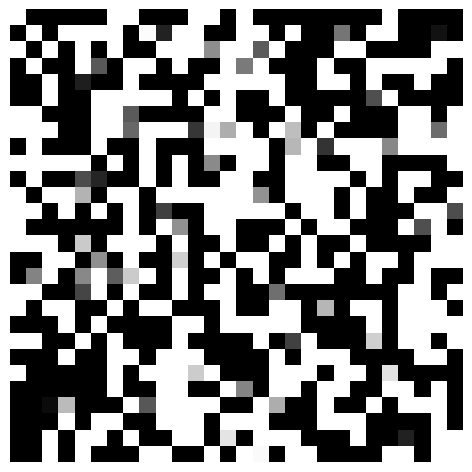

In [ ]:
perturbed_img = images + z * std[:, None, None, None]
show_batch(perturbed_img.cpu())

In [ ]:
score_model = torch.nn.DataParallel(ScoreNet(marginal_prob_std=marginal_prob_std_fn))
score_model = score_model.to(device)
print(random_t.shape)
#score_img = score_model(perturbed_img, random_t)

## Print the summary of the model
summary(score_model, input_data=[perturbed_img, random_t])

torch.Size([1])


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  del sys.path[0]


Layer (type:depth-idx)                             Output Shape              Param #
DataParallel                                       [1, 1, 28, 28]            --
├─ScoreNet: 1-1                                    [1, 1, 28, 28]            --
│    └─Sequential: 2-1                             [1, 256]                  --
│    │    └─GaussianFourierProjection: 3-1         [1, 256]                  (128)
│    │    └─Linear: 3-2                            [1, 256]                  65,792
│    └─Conv2d: 2-2                                 [1, 32, 26, 26]           288
│    └─Dense: 2-3                                  [1, 32, 1, 1]             --
│    │    └─Linear: 3-3                            [1, 32]                   8,224
│    └─GroupNorm: 2-4                              [1, 32, 26, 26]           64
│    └─Conv2d: 2-5                                 [1, 64, 12, 12]           18,432
│    └─Dense: 2-6                                  [1, 64, 1, 1]             --
│    │    └─Linear: 

In [ ]:
# Generate image for medium article
t = torch.logspace(-2., 1, 7)
print(t)

# Calculate the variance 
std = marginal_prob_std_fn(t).to(device)
print(std.shape)
print(std[:, None, None, None].shape)

tensor([1.0000e-02, 3.1623e-02, 1.0000e-01, 3.1623e-01, 1.0000e+00, 3.1623e+00,
        1.0000e+01])
torch.Size([7])
torch.Size([7, 1, 1, 1])


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  del sys.path[0]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([7, 1, 28, 28])


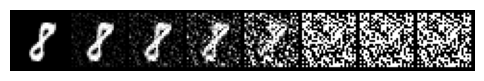

In [ ]:
perturbed_img = images[0] + z * std[:, None, None, None]
print(perturbed_img.shape)
final_img = torch.cat((images, perturbed_img), dim=0) 
show_batch(final_img.cpu())

# Working with the retinal dataset

In [ ]:
# Define a dataset class for the retinal dataset

class myDataset(Dataset):
    def __init__(self, root_A, root_B, transform=None):
        self.root_A = root_A
        self.root_B = root_B
        self.transform = transform

        self.A_images = os.listdir(root_A)
        self.B_images = os.listdir(root_B)
        
        self.length_dataset = max(len(self.A_images), len(self.B_images))
        self.A_len = len(self.A_images)
        self.B_len = len(self.B_images)
        
    def __len__(self):
        return self.length_dataset

    def __getitem__(self, index):
        A_img = self.A_images[index % self.A_len]
        B_img = self.B_images[index % self.B_len]
        
        A_path = os.path.join(self.root_A, A_img)
        B_path = os.path.join(self.root_B, B_img)
        
        A_img = Image.open(A_path).convert("RGB")
        B_img = Image.open(B_path).convert("RGB")
        
        if self.transform:
            A_img = self.transform(A_img)
            B_img = self.transform(B_img)

        return A_img, B_img

In [ ]:
# Load and transform the retinal dataset

transformation = transforms.Compose(
    [transforms.Resize((256, 256)),
     transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

train_dataset = myDataset(
    root_A="./data/trainA", 
    root_B="./data/trainB", 
    transform=transformation
)

loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True
)

In [ ]:
img1, img2 = next(iter(loader))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


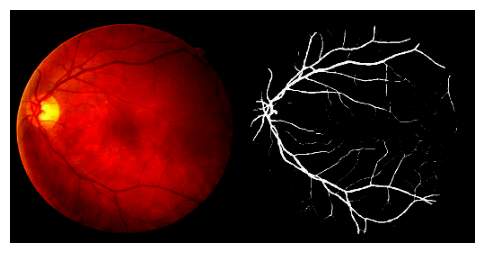

In [ ]:
img1 = img1.to(device)
img2 = img2.to(device)

show_batch([torch.squeeze(img1.cpu()), torch.squeeze(img2.cpu())])

In [ ]:
# Time
t1 = torch.linspace(0, 1, 7)
print(t1)

# Generate random noise for the image
z1 = torch.randn_like(img1).to(device)
z2 = torch.randn_like(img2).to(device)

# Calculate the variance 
std1 = marginal_prob_std_fn(t1).to(device)
std2 = marginal_prob_std_fn(t1).to(device)

tensor([0.0000, 0.1667, 0.3333, 0.5000, 0.6667, 0.8333, 1.0000])


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  del sys.path[0]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


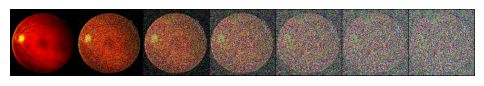

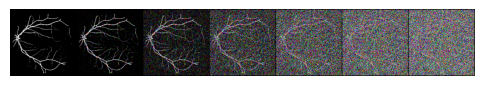

In [ ]:
perturbed_img1 = img1 + z1 * std1[:, None, None, None]
perturbed_img2 = img2 + z2 * std2[:, None, None, None]
show_batch(perturbed_img1.cpu())
show_batch(perturbed_img2.cpu())

# Calculating the output of the ScoreNet function and the Loss function for a single retinal image


In [ ]:
img1.shape

torch.Size([1, 3, 256, 256])

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  del sys.path[0]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


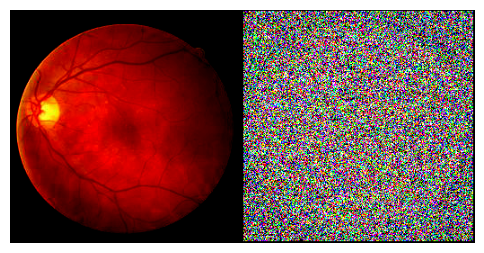

In [ ]:
eps=1e-5
random_t = torch.rand(img1.shape[0], device=img1.device) * (1. - eps) + eps 
std = marginal_prob_std_fn(random_t).to(device)

# Generate the Gaussian Noise and perturb the image
z = torch.randn_like(img1).to(device)
perturbed_img1 = img1 + z * std[:, None, None, None]
show_batch([torch.squeeze(img1).cpu(), torch.squeeze(perturbed_img1).cpu()])

In [ ]:
# Calculate the score
score_model = torch.nn.DataParallel(ScoreNet(marginal_prob_std=marginal_prob_std_fn))
score_model = score_model.to(device)

## Print the summary of the model
summary(score_model, input_data=[perturbed_img1, random_t])

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  del sys.path[0]


Layer (type:depth-idx)                             Output Shape              Param #
DataParallel                                       [1, 3, 256, 256]          --
├─ScoreNet: 1-1                                    [1, 3, 256, 256]          --
│    └─Sequential: 2-1                             [1, 256]                  --
│    │    └─GaussianFourierProjection: 3-1         [1, 256]                  (128)
│    │    └─Linear: 3-2                            [1, 256]                  65,792
│    └─Conv2d: 2-2                                 [1, 32, 254, 254]         864
│    └─Dense: 2-3                                  [1, 32, 1, 1]             --
│    │    └─Linear: 3-3                            [1, 32]                   8,224
│    └─GroupNorm: 2-4                              [1, 32, 254, 254]         64
│    └─Conv2d: 2-5                                 [1, 64, 126, 126]         18,432
│    └─Dense: 2-6                                  [1, 64, 1, 1]             --
│    │    └─Linear: 

In [ ]:
score_img = score_model(perturbed_img1, random_t)
loss = torch.mean(torch.sum((score_img * std[:, None, None, None] + z)**2, dim=(1,2,3)))
print(loss)

tensor(768034.3125, device='cuda:0', grad_fn=<MeanBackward0>)


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  del sys.path[0]


## Training the model

In [ ]:
n_epochs =   50
lr=1e-4

optimizer = Adam(score_model.parameters(), lr=lr)
tqdm_epoch = tqdm.notebook.trange(n_epochs)

for epoch in tqdm_epoch:
  avg_loss = 0.
  num_items = 0
  for x, y in data_loader:
    x = x.to(device)    
    loss = loss_fn(score_model, x, marginal_prob_std_fn)
    optimizer.zero_grad()
    loss.backward()    
    optimizer.step()
    avg_loss += loss.item() * x.shape[0]
    num_items += x.shape[0]
  # Print the averaged training loss so far.
  tqdm_epoch.set_description('Average Loss: {:5f}'.format(avg_loss / num_items))
  # Update the checkpoint after each epoch of training.
  torch.save(score_model.state_dict(), 'ckpt.pth')

# Sampling with Numerical SDE

In [ ]:
## The number of sampling steps.
num_steps =  500
def Euler_Maruyama_sampler(score_model, 
                           marginal_prob_std,
                           diffusion_coeff, 
                           batch_size=64, 
                           num_steps=num_steps, 
                           device='cuda', 
                           eps=1e-3):
  """Generate samples from score-based models with the Euler-Maruyama solver.

  Args:
    score_model: A PyTorch model that represents the time-dependent score-based model.
    marginal_prob_std: A function that gives the standard deviation of
      the perturbation kernel.
    diffusion_coeff: A function that gives the diffusion coefficient of the SDE.
    batch_size: The number of samplers to generate by calling this function once.
    num_steps: The number of sampling steps. 
      Equivalent to the number of discretized time steps.
    device: 'cuda' for running on GPUs, and 'cpu' for running on CPUs.
    eps: The smallest time step for numerical stability.
  
  Returns:
    Samples.    
  """
  t = torch.ones(batch_size, device=device)
  init_x = torch.randn(batch_size, 1, 28, 28, device=device) \
    * marginal_prob_std(t)[:, None, None, None]
  time_steps = torch.linspace(1., eps, num_steps, device=device)
  step_size = time_steps[0] - time_steps[1]
  x = init_x
  with torch.no_grad():
    for time_step in tqdm.notebook.tqdm(time_steps):      
      batch_time_step = torch.ones(batch_size, device=device) * time_step
      g = diffusion_coeff(batch_time_step)
      mean_x = x + (g**2)[:, None, None, None] * score_model(x, batch_time_step) * step_size
      x = mean_x + torch.sqrt(step_size) * g[:, None, None, None] * torch.randn_like(x)      
  # Do not include any noise in the last sampling step.
  return mean_x